In [2]:
import numpy as np
import pandas as pd
import json

from src.simulation.synthetic_worlds.fair_world import simulate_fair_world
from src.simulation.preprocessing import preprocess

# Models
from src.simulation.train_lr_sim import train_logistic_regression
from src.simulation.train_mlp_sim import train_mlp_model, MLP_Realistic

# Metrics
from src.metrics.evaluation import evaluate_model


SEED = 42


In [3]:
df = simulate_fair_world(n_samples=10000, seed=SEED)

df.head()


,race,gender,age,glucose_measured,hba1c_measured,diabetes_label
0,0,0,66.807657,86.260274,5.264139,0
1,2,1,49.977538,94.787618,4.977199,0
2,1,1,41.819978,88.619829,5.321474,0
3,0,1,51.230187,103.810522,5.338681,0
4,0,0,44.494660,165.847420,7.429512,1


In [4]:
features = ["age", "glucose_measured", "hba1c_measured"]
target = "diabetes_label"

X_train_s, X_test_s, y_train, y_test, scaler = preprocess(
    df,
    feature_cols=features,
    label_col=target,
    test_size=0.3
)

print("Train size:", len(X_train_s))
print("Test size:", len(X_test_s))
print("Train diabetes prevalence:", y_train.mean())
print("Test diabetes prevalence:", y_test.mean())


Train size: 7000
Test size: 3000
Train diabetes prevalence: 0.201
Test diabetes prevalence: 0.18666666666666668


In [5]:
lr_out = train_logistic_regression(X_train_s, y_train, X_test_s, y_test)

print("LR Accuracy:", lr_out["accuracy"])


LR Accuracy: 0.9986666666666667
LR AUROC: 0.9999216920374707


Epoch 1/30: train_loss=0.0979, train_acc=95.86, val_loss=0.0063, val_acc=99.83
Epoch 2/30: train_loss=0.0048, train_acc=99.87, val_loss=0.0054, val_acc=99.90
Epoch 3/30: train_loss=0.0039, train_acc=99.87, val_loss=0.0050, val_acc=99.90
Epoch 4/30: train_loss=0.0030, train_acc=99.91, val_loss=0.0062, val_acc=99.90
Epoch 5/30: train_loss=0.0037, train_acc=99.89, val_loss=0.0117, val_acc=99.77
Epoch 6/30: train_loss=0.0030, train_acc=99.89, val_loss=0.0047, val_acc=99.90
Epoch 7/30: train_loss=0.0024, train_acc=99.90, val_loss=0.0050, val_acc=99.90
Epoch 8/30: train_loss=0.0024, train_acc=99.90, val_loss=0.0083, val_acc=99.83
Epoch 9/30: train_loss=0.0023, train_acc=99.90, val_loss=0.0081, val_acc=99.87
Epoch 10/30: train_loss=0.0027, train_acc=99.91, val_loss=0.0074, val_acc=99.87
Epoch 11/30: train_loss=0.0024, train_acc=99.93, val_loss=0.0072, val_acc=99.87
Epoch 12/30: train_loss=0.0021, train_acc=99.91, val_loss=0.0047, val_acc=99.90
Epoch 13/30: train_loss=0.0022, train_acc=99.91, 

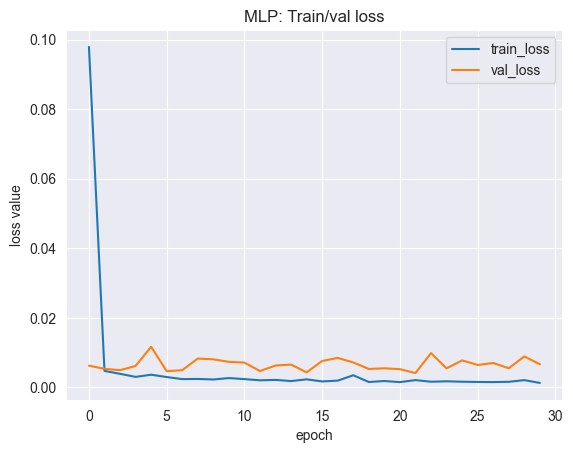

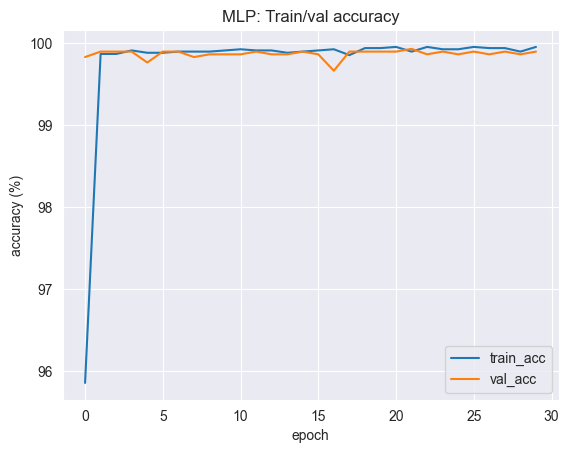

In [6]:
nn_out = train_mlp_model(
    X_train_s, y_train,
    X_test_s, y_test,
    input_dim=len(features),
    n_epochs=30,
    lr=0.001,
    model_class=MLP_Realistic
)

print("NN Accuracy:", nn_out["accuracy"])
print("NN AUROC:", nn_out["AUROC"])


In [7]:
sens_test = df.iloc[y_test.index][["gender", "race"]]
sens_test.head()


,gender,race
6252,1,0
4684,0,1
1731,1,1
4742,0,0
4521,0,0


In [8]:
fair_lr = evaluate_model(
    y_true=y_test.values,
    y_pred=lr_out["pred"],
    y_prob=lr_out["probs"],
    sens_test=sens_test
)

fair_lr


{'accuracy': 0.9986666666666667,
 'precision': 1.0,
 'recall': 0.9928571428571429,
 'gender_metrics': {np.int64(1): {'TPR': 0.9964788732394366,
   'FNR': 0.0035211267605633756,
   'Precision': 1.0,
   'Calibration': 0.0010778055989484046},
  np.int64(0): {'TPR': 0.9891304347826086,
   'FNR': 0.010869565217391353,
   'Precision': 1.0,
   'Calibration': 0.0015236296034993938}},
 'gender_gap': 0.007348438456827977,
 'race_metrics': {np.int64(0): {'TPR': 0.9913544668587896,
   'FNR': 0.008645533141210415,
   'Precision': 1.0,
   'Calibration': 0.0014263489209419963},
  np.int64(1): {'TPR': 0.9924242424242424,
   'FNR': 0.007575757575757569,
   'Precision': 1.0,
   'Calibration': 0.0016615565418062795},
  np.int64(2): {'TPR': 1.0,
   'FNR': 0.0,
   'Precision': 1.0,
   'Calibration': 0.00013590607450479788}},
 'race_gap': 0.008645533141210415}

In [9]:
fair_nn = evaluate_model(
    y_true=y_test.values,
    y_pred=nn_out["pred"],
    y_prob=nn_out["probs"],
    sens_test=sens_test
)

fair_nn


{'accuracy': 0.999,
 'precision': 1.0,
 'recall': 0.9946428571428572,
 'gender_metrics': {np.int64(1): {'TPR': 0.9964788732394366,
   'FNR': 0.0035211267605633756,
   'Precision': 1.0,
   'Calibration': 0.0006985474188239189},
  np.int64(0): {'TPR': 0.9927536231884058,
   'FNR': 0.007246376811594235,
   'Precision': 1.0,
   'Calibration': 0.001339106501953618}},
 'gender_gap': 0.0037252500510308595,
 'race_metrics': {np.int64(0): {'TPR': 0.9942363112391931,
   'FNR': 0.0057636887608069065,
   'Precision': 1.0,
   'Calibration': 0.001097087148220835},
  np.int64(1): {'TPR': 0.9924242424242424,
   'FNR': 0.007575757575757569,
   'Precision': 1.0,
   'Calibration': 0.0014012024888816776},
  np.int64(2): {'TPR': 1.0,
   'FNR': 0.0,
   'Precision': 1.0,
   'Calibration': 4.5745359669611564e-07}},
 'race_gap': 0.007575757575757569}